In [1]:
import pandas as pd
import numpy as np

# Load CSV (handles extra trailing commas)
df = pd.read_csv(
    "credit_card_unsupervised_transactions_random_count.csv",
    usecols=["customer_id", "transaction_id", "transaction_date",
             "transaction_amount", "merchant_category"]
)

# Basic cleaning
df.columns = df.columns.str.strip()
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["transaction_amount"] = pd.to_numeric(df["transaction_amount"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["customer_id", "transaction_amount", "merchant_category"])

print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: 'credit_card_unsupervised_transactions_random_count.csv'

In [ ]:
# Total transactions
txn_count = df.groupby("customer_id")["transaction_id"].count()

# Average transaction value
avg_txn_value = df.groupby("customer_id")["transaction_amount"].mean()

# Activity frequency (transactions per active day)
active_days = df.groupby("customer_id")["transaction_date"].nunique()
txn_per_day = txn_count / active_days

# Category ratios
category_pivot = (
    df.pivot_table(
        index="customer_id",
        columns="merchant_category",
        values="transaction_amount",
        aggfunc="sum",
        fill_value=0
    )
)

# Normalize category spend to ratios
category_ratio = category_pivot.div(category_pivot.sum(axis=1), axis=0)

# Final feature table
features = pd.concat(
    [txn_count, avg_txn_value, txn_per_day, category_ratio],
    axis=1
)

features.columns = (
    ["txn_count", "avg_txn_value", "txn_per_day"] +
    list(category_ratio.columns)
)

print(features.head())


             txn_count  avg_txn_value  txn_per_day    Dining  Entertainment  \
customer_id                                                                   
CUST00000           28   35003.705357     1.076923  0.369095       0.067042   
CUST00001            7    1102.082857     1.000000  0.000000       0.000000   
CUST00002           53    7392.142264     1.177778  0.269432       0.266483   
CUST00003           76     976.804342     1.245902  0.038870       0.011496   
CUST00004          136     319.861912     1.478261  0.140889       0.050544   

                 Fuel   Grocery  Online Shopping    Travel  Utilities  
customer_id                                                            
CUST00000    0.120086  0.047725         0.184616  0.202831   0.008605  
CUST00001    0.262808  0.030298         0.123392  0.567608   0.015893  
CUST00002    0.013546  0.041324         0.014701  0.327362   0.067152  
CUST00003    0.322347  0.316501         0.097979  0.090893   0.121915  
CUST00004    0

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=42)  # keep 90% variance
pca_features = pca.fit_transform(scaled_features)

print("PCA Components:", pca.n_components_)


PCA Components: 7


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(pca_features)

features["cluster_id"] = clusters


In [ ]:
cluster_profile = features.groupby("cluster_id").mean()
print(cluster_profile)


             txn_count  avg_txn_value  txn_per_day    Dining  Entertainment  \
cluster_id                                                                    
0            32.553942   15507.750813     1.094667  0.266074       0.085497   
1            44.992145    1154.553536     1.125954  0.054405       0.029694   
2           113.360518     387.211827     1.353163  0.147862       0.051290   
3             8.143519    6039.488822     1.021768  0.079731       0.052928   
4             8.096552    5085.370982     1.022423  0.080942       0.515561   

                Fuel   Grocery  Online Shopping    Travel  Utilities  
cluster_id                                                            
0           0.053325  0.058452         0.105138  0.314569   0.116946  
1           0.322516  0.464055         0.040734  0.049528   0.039068  
2           0.252540  0.351936         0.099024  0.049104   0.048244  
3           0.058437  0.137662         0.520356  0.084820   0.066066  
4           0.077809

In [ ]:
cluster_name_map = {
    0: "High txn count / Low avg value – Daily Spender",
    1: "Low txn count / High avg value – Premium User",
    2: "High Groceries/Fuel ratio – Household User",
    3: "High Travel & Dining – Lifestyle User",
    4: "Low Activity – Dormant User"
}

features["customer_segment"] = features["cluster_id"].map(cluster_name_map)


In [ ]:
final_output = features.reset_index()[[
    "customer_id", "customer_segment"
]]

print(final_output.head())

# Save results
final_output.to_csv("customer_segments.csv", index=False)


  customer_id                                customer_segment
0   CUST00000  High txn count / Low avg value – Daily Spender
1   CUST00001  High txn count / Low avg value – Daily Spender
2   CUST00002  High txn count / Low avg value – Daily Spender
3   CUST00003   Low txn count / High avg value – Premium User
4   CUST00004      High Groceries/Fuel ratio – Household User


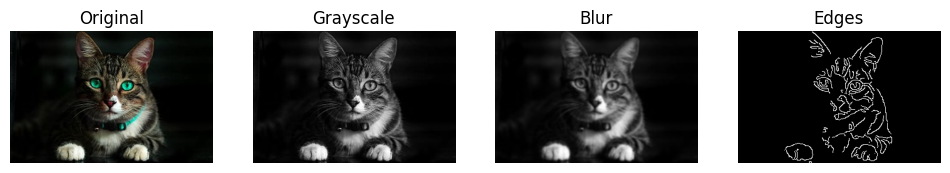

In [4]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("OIP.jpg")   

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blur, 100, 200)



plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(blur, cmap='gray')
plt.title("Blur")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis("off")

plt.show()

In [12]:
import cv2
import pytesseract
import re

image = cv2.imread("sample-pan-card.jpg")

if image is None:
    raise FileNotFoundError("Image not found")

# Resize (important for OCR)
image = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Threshold
thresh = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)[1]

# OCR config optimized for PAN
config = r'-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 --psm 6'

text = pytesseract.image_to_string(thresh, config=config)

# Regex for PAN number
pan_pattern = r'[A-Z]{5}[0-9]{4}[A-Z]'
match = re.search(pan_pattern, text)

if match:
    print("PAN Number:", match.group())
else:
    print("PAN Number not found")


PAN Number: ABCDE1234F



image 1/1 c:\Users\Administrator\Desktop\ML_MBRDI\OIP.jpg: 448x640 1 cat, 97.7ms
Speed: 2.9ms preprocess, 97.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Class: cat Confidence: 0.916 Coordinates: (9, 1, 261, 207)


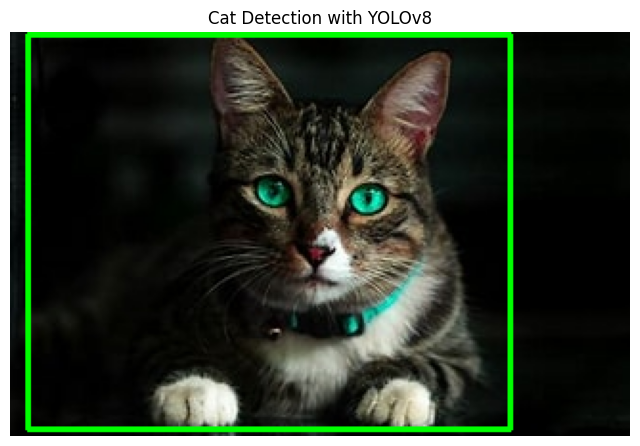

In [14]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Image path
image_path = "OIP.jpg"

# Read image using OpenCV
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Run YOLO detection
results = model(image_path)

# Class names
names = results[0].names

# Draw bounding boxes
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        label = names[cls_id]

        # Bounding box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        print(
            "Class:", label,
            "Confidence:", round(conf, 3),
            "Coordinates:", (x1, y1, x2, y2)
        )

        # Draw rectangle
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Draw label
        cv2.putText(
            image,
            f"{label} {conf:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

# Convert BGR to RGB for matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image in Jupyter
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Cat Detection with YOLOv8")
plt.show()



image 1/1 c:\Users\Administrator\Desktop\ML_MBRDI\people.jpg: 288x640 20 persons, 71.9ms
Speed: 2.4ms preprocess, 71.9ms inference, 1.0ms postprocess per image at shape (1, 3, 288, 640)
Number of people detected: 20


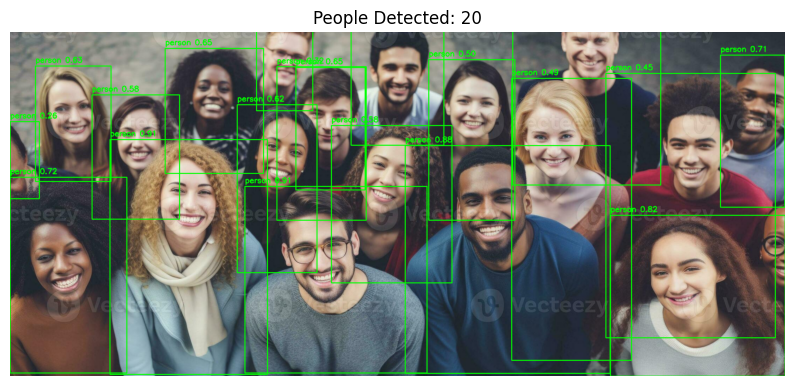

In [15]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Image path
image_path = "people.jpg"  # replace with your image

# Read image
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Run detection
results = model(image_path)

# Class names
names = results[0].names

# Counter for people
people_count = 0

# Draw bounding boxes
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls)
        label = names[cls_id]

        if label == "person":
            people_count += 1

            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw rectangle around person
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Draw label + confidence
            conf = float(box.conf)
            cv2.putText(
                image,
                f"{label} {conf:.2f}",
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

# Print total people
print("Number of people detected:", people_count)

# Display image in Jupyter
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title(f"People Detected: {people_count}")
plt.show()
